# 08 - The inverter assumption, checked with a dynamic inverter model in the loop

Every notebook so far treats a PV inverter as a static device: given its terminal voltage
and its volt-var curve, OpenDSS assumes it delivers the reactive power the curve asks for,
instantly and exactly. This notebook checks that assumption. The four far units of feeder 1
(buses 7, 9, 10 and 11, where the OPF of notebook 04 puts most of the absorption) are taken
out of OpenDSS and replaced by dynamic inverter models running in Typhoon HIL, with the same
volt-var curve and the same curve points the trained agent of notebook 06 chose. The two
programs exchange bus voltages and inverter powers once a second, in the manner of the
real-time co-simulation of Wagle et al. (IET GTD 2023), and the day is compared with the
OpenDSS-only run of notebook 06.

Two things come out of it. Over the sunniest day of the year the dynamic inverters
reproduce the study's voltages and reactive powers to within 0.0005 pu and about 1 kvar,
so the static assumption holds at 15-minute resolution. Between two 15-minute points,
however, there are a few seconds the study never saw, and they are shown here once.

The Typhoon side ran in Virtual HIL, the software-only mode of Typhoon HIL Control Center
2023.4, so nothing here is real time. The cells that build the inverter model and run the
loop execute only when the Typhoon software and its Python API are installed; otherwise
the notebook reads the saved results in `results/` and produces the same figures.

In [1]:
# Paths: this notebook runs from notebooks/, the modules live in src/ and every
# generated file in results/, so the working directory is moved there once.
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    sys.path.insert(0, os.path.abspath(os.path.join(os.pardir, "src")))
    os.makedirs(os.path.join(os.pardir, "results"), exist_ok=True)
    os.chdir(os.path.join(os.pardir, "results"))

import importlib.util, json, math, time
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import simulate as sim
from env import VoltVarEnv, EnvConfig, curve_to_action, dss

T_NB0 = time.perf_counter()
plt.rcParams.update({"font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10,
                     "legend.fontsize": 9, "figure.dpi": 100})

# The Typhoon parts run only with the software present: its Python API importable
# and TYPHOONPATH pointing at the installation (e.g. C:\Program Files\Typhoon HIL Control Center 2023.4 sp1).
HAVE_TYPHOON = importlib.util.find_spec("typhoon") is not None and bool(os.environ.get("TYPHOONPATH"))
REBUILD = False          # True: rebuild and recompile the Typhoon model even if it exists
RERUN = False            # True: rerun the co-simulation even if results/hil_day171.csv exists
print("Typhoon HIL API available:", HAVE_TYPHOON)

DAY, SEED = 171, 0                       # the sunniest day of the year, seed 0 best checkpoint
UNITS = (7, 9, 10, 11)                   # the far units, handed over to Typhoon
IDX = [sim.PV_BUSES.index(b) for b in UNITS]
VN, FN = 400.0, 50.0                     # the Typhoon inverter is a 400 V, 50 Hz unit
P_TYPH, SN_TYPH = 250e3, 275e3           # 250 kW panel, 1.1 x Pmpp inverter, as in the study
SCALE = {b: sim.PV_KW[j] * 1e3 / P_TYPH for b, j in zip(UNITS, IDX)}   # 740/250 for all four
HANDSHAKES, WAIT_MS = 8, 1000
print("units and scale to feeder size:", {b: round(s, 2) for b, s in SCALE.items()})

Typhoon HIL API available: True
units and scale to feeder size: {7: np.float64(2.96), 9: np.float64(2.96), 10: np.float64(2.96), 11: np.float64(2.96)}


## 1. The setup: a feeder in one program, four inverters in another

OpenDSS keeps the whole feeder, its loads, the transformer and five of the nine PV units,
exactly as in notebook 06. The units at buses 7, 9, 10 and 11 keep their PVSystem element
but lose their InvControl: their P and Q are written in from outside. Outside is Typhoon
HIL, running four copies of one inverter model: a 250 kW PV panel, the library block
"PV inverter (Average)" (DC-link control, MPPT, current control, 275 kVA, 400 V, 50 Hz),
and a small controller built from primitives that reads the terminal voltage, converts it
to per unit, filters it with a 1 s time constant (standing in for the open-loop response
time of IEEE 1547-2018, whose Category B default is 5 s) and evaluates the volt-var curve.
The three upper points V3, V4, Q4 are inputs that can be changed while the model runs.

The two programs meet once a second, as in the real-time framework of Wagle et al.:

1. OpenDSS solves the feeder and reports the four bus voltages.
2. Each Typhoon inverter's grid source is set so that its measured terminal equals its bus
   voltage (the block measures behind a small internal impedance, so the source is
   corrected by the mismatch of the previous exchange).
3. After one second of Typhoon time, each inverter's P and Q are read, scaled from the
   250 kW unit to the 740 kW unit of the study, and written into its PVSystem.
4. OpenDSS solves again.

Eight exchanges are made per 15-minute step, then the curve points of the next step (the
agent's, for all nine units) and the next irradiance are applied. Night steps are skipped.
The reference is the OpenDSS-only run of seed 0 (notebook 06), before the safety layer.

## 2. Building the inverter model

The model is drawn by script through Typhoon's schematic API, so that the four copies are
identical and the drawing can be regenerated. The curve is a few lines of C in a function
block, with the same fixed lower half (V1 0.92, Q1 +0.44, V2 0.98) as `env.py`. Four
inverters need four processing cores, so the model targets a HIL604; a HIL402 or 404 has
three cores and takes the single-inverter version only. Compiling takes about two minutes
and writes the binary the next section loads. The panel curve file `PV_250KW.ipvx` ships
with Typhoon and is read from the installation.

In [2]:
HIL_DIR = os.path.abspath("hil_model")                 # results/hil_model/
TSE = os.path.join(HIL_DIR, "voltvar_pv4.tse")
CPD = os.path.join(HIL_DIR, "voltvar_pv4 Target files", "voltvar_pv4.cpd")

def typhoon_example_panel():
    root = os.environ.get("TYPHOONPATH", "")
    return os.path.join(root, "examples", "models", "microgrid", "pv plant", "pv inverter (average)", "PV_250KW.ipvx")

def build_model():
    '''Four volt-var inverters, one per far bus, each directly on its own grid source.'''
    from typhoon.api.schematic_editor import model as mdl
    os.makedirs(HIL_DIR, exist_ok=True)
    VT_NOM = VN * math.sqrt(2.0 / 3.0)                  # the block reports Vt as phase peak
    curve_c = '''
const double V1 = 0.92, Q1 = 0.44, V2 = 0.98;
if (v <= V1)       q = Q1;
else if (v < V2)   q = Q1 * (V2 - v) / (V2 - V1);
else if (v <= V3)  q = 0.0;
else if (v < V4)   q = -Q4 * (v - V3) / (V4 - V3);
else               q = -Q4;
'''
    mdl.create_new_model("voltvar_pv4")
    mdl.set_hw_settings("HIL604", 1, 1)
    def comp(t, name, pos, **props):
        h = mdl.create_component(t, name=name, position=pos)
        for k, v in props.items():
            mdl.set_property_value(mdl.prop(h, k), v)
        return h
    def wire(a, ta, b, tb):
        mdl.create_connection(mdl.term(a, ta), mdl.term(b, tb))
    def scada(name, pos, default, lo, hi):
        return comp("core/SCADA Input", name, pos, def_value=default, min=lo, max=hi)
    for n, b in enumerate(UNITS):
        y0, s = 7600 + 1400 * n, str(b)
        panel = comp("core/Photovoltaic Panel", "PVpanel" + s, (7900, y0))
        inv = comp("core/PV inverter (Average)", "Inverter" + s, (8500, y0), Sn=SN_TYPH, Vn=VN, fn=FN, Vdc=1000.0)
        grid = comp("core/Three Phase Voltage Source", "Grid" + s, (9300, y0), init_frequency=FN)
        wire(panel, "p_node", inv, "DC+"); wire(panel, "n_node", inv, "DC-")
        for ph in "ABC":
            wire(inv, ph, grid, f"{ph.lower()}_node")
        on = scada("On" + s, (7900, y0 + 450), 0.0, 0.0, 1.0)      # switched on after the PLL has locked
        v3 = scada("V3_" + s, (7900, y0 + 550), 1.02, 1.00, 1.03)
        v4 = scada("V4_" + s, (7900, y0 + 650), 1.08, 1.02, 1.18)
        q4 = scada("Q4_" + s, (7900, y0 + 750), 0.44, 0.00, 0.44)
        split = comp("core/Bus Split", "Outputs" + s, (8500, y0 + 450), outputs=[14])
        wire(inv, "Outputs", split, "in")
        to_pu = comp("core/Gain", "to_pu" + s, (8800, y0 + 550), gain=[1.0 / VT_NOM])
        wire(split, "out5", to_pu, "in")                             # Out[5] = terminal voltage
        wire(to_pu, "out", comp("core/Probe", "V_pu_" + s, (9050, y0 + 450)), "in")
        lpf = comp("core/Low-Pass Filter", "V_filter" + s, (8850, y0 + 700), frequency=[1.0 / (2 * math.pi * 1.0)], init_out=[1.0])
        wire(to_pu, "out", lpf, "in")
        curve = comp("core/gen_c_function", "VoltVar" + s, (9100, y0 + 700),
                     input_terminals="real v; real V3; real V4; real Q4;", input_terminals_show_labels="True; True; True; True;",
                     output_terminals="real q;", output_terminals_show_labels="True;", output_fnc=curve_c)
        wire(lpf, "out", curve, "v"); wire(v3, "out", curve, "V3"); wire(v4, "out", curve, "V4"); wire(q4, "out", curve, "Q4")
        wire(curve, "q", comp("core/Probe", "q_pu_" + s, (9400, y0 + 600)), "in")
        to_var = comp("core/Gain", "to_var" + s, (9400, y0 + 750), gain=[SN_TYPH])
        wire(curve, "q", to_var, "in")
        join = comp("core/Bus Join", "Inputs" + s, (9700, y0 + 600), inputs=2)
        wire(on, "out", join, "in"); wire(to_var, "out", join, "in1"); wire(join, "out", inv, "Inputs")
        wire(split, "out10", comp("core/Probe", "P_W_" + s, (8800, y0 + 850)), "in")
        wire(split, "out11", comp("core/Probe", "Q_var_" + s, (8800, y0 + 950)), "in")
    mdl.save_as(TSE)
    ok = mdl.compile()
    print("model saved to", os.path.relpath(TSE, os.pardir), "- compiled:", ok)
    return ok

if HAVE_TYPHOON and (REBUILD or not os.path.exists(CPD)):
    build_model()
else:
    print("Typhoon model", "found" if os.path.exists(CPD) else "not built here", "-", os.path.relpath(CPD, os.pardir))

Typhoon model found - results\hil_model\voltvar_pv4 Target files\voltvar_pv4.cpd


## 3. The co-simulation

The loop below is the four-step exchange of section 1 in code. Two details matter in
practice. The inverters are switched on two seconds after the simulation starts, once their
PLLs have locked; switched on at once, the DC link runs away and every reading is garbage.
And the terminal correction of step 2 is not optional: without it each inverter reacts to a
terminal voltage one to three percent above its bus voltage and absorbs 1.6 to 2 times the
reactive power it should. At the 11:30 step, where the irradiance jumps from 0.28 to 0.93,
a capture of all eight signals at 10 ms is started for the first nine seconds, so one
transient is kept.

Runtime is about 22 minutes in Virtual HIL for the 47 daylight steps. Without Typhoon the
cell loads `results/hil_day171.csv` and `results/hil_transient_1130.csv`.

In [3]:
DAY_CSV, TR_CSV = "hil_day171.csv", "hil_transient_1130.csv"
CAPTURE_AT = "11:30"

def run_cosim():
    import typhoon.api.hil as hil
    with h5py.File("train_2023.h5") as f:
        g = f[f"seed{SEED}/best_run"]
        steps = np.arange(DAY * 96, (DAY + 1) * 96)
        curves = g["curves"][steps]; ref_v = g["v_before"][steps]
        ref_q = g["q_kvar"][steps]; ref_p = g["p_kw"][steps]; ref_irr = g["irr"][steps]
    E = VoltVarEnv(EnvConfig(safety_layer=False))
    E.reset(day=DAY)
    for b in UNITS:
        dss.Text.Command(f"invcontrol.ic{b}.enabled=no")
    def dss_set(b, p_w, q_var):
        dss.PVsystems.Name(f"pv{b}")
        dss.PVsystems.Irradiance(float(min(1.0, max(0.0, p_w / (sim.PV_KW[sim.PV_BUSES.index(b)] * 1e3)))))
        dss.PVsystems.kvar(float(q_var / 1e3))
    def dss_v():
        v = sim.feeder1_voltages()
        return {b: float(v[sim.F1_BUSES.index(b)]) for b in UNITS}
    def typh_grid(vd):
        for b in UNITS:
            hil.set_source_sine_waveform(f"Grid{b}", rms=vd[b] * VN / math.sqrt(3), frequency=FN, phase=0.0)
    def typh_read():
        return {b: (hil.read_analog_signal(name=f"P_W_{b}"), hil.read_analog_signal(name=f"Q_var_{b}"),
                    hil.read_analog_signal(name=f"V_pu_{b}")) for b in UNITS}

    assert hil.load_model(CPD, vhil_device=True)
    for b in UNITS:
        hil.set_source_sine_waveform(f"Grid{b}", rms=VN / math.sqrt(3), frequency=FN, phase=0.0)
        hil.set_pv_input_file(f"PVpanel{b}", file=typhoon_example_panel(), illumination=1000.0, temperature=25.0)
    assert hil.start_simulation()
    hil.wait_msec(2000)                                  # PLL lock first
    for b in UNITS:
        hil.set_scada_input_value(f"On{b}", 1.0)
    hil.wait_msec(12000)                                 # MPPT climbs to the MPP

    cap_sigs = [f"Q_var_{b}" for b in UNITS] + [f"V_pu_{b}" for b in UNITS]
    cap_buf, rows = [], []
    for k, i in enumerate(steps):
        if ref_irr[k].max() < 0.05:
            continue
        hh, mm = divmod(15 * (i % 96), 60); tlab = f"{hh:02d}:{mm:02d}"
        E._apply_profile(i)
        E.set_curves(curve_to_action(curves[k, :, 0], curves[k, :, 1], curves[k, :, 2]))
        for b, j in zip(UNITS, IDX):
            for n, val in zip(("V3", "V4", "Q4"), curves[k, j]):
                hil.set_scada_input_value(f"{n}_{b}", float(val))
            hil.set_pv_amb_params(f"PVpanel{b}", illumination=float(ref_irr[k, j] * 1000.0), temperature=25.0)
        if tlab == CAPTURE_AT:
            dec = max(1, int(round(0.01 / hil.get_sim_step())))
            assert hil.start_capture([dec, len(cap_sigs), 900, False], ["Forced"], [cap_sigs, []], dataBuffer=cap_buf)
        for h in range(HANDSHAKES):
            E._solve()
            vd = dss_v()
            cmd = dict(vd) if h == 0 else {b: cmd[b] + (vd[b] - r[b][2]) for b in UNITS}   # terminal = bus
            typh_grid(cmd)
            hil.wait_msec(WAIT_MS)
            r = typh_read()
            for b in UNITS:
                dss_set(b, r[b][0] * SCALE[b], r[b][1] * SCALE[b])
        if tlab == CAPTURE_AT:
            t0 = time.time()
            while hil.capture_in_progress() and time.time() - t0 < 120:
                time.sleep(0.2)
        E._solve()
        vd = dss_v()
        row = {"time": tlab}
        for b, j in zip(UNITS, IDX):
            row.update({f"V_dss_{b}": ref_v[k, sim.F1_BUSES.index(b)], f"V_cosim_{b}": vd[b],
                        f"Q_dss_kvar_{b}": ref_q[k, j], f"Q_cosim_kvar_{b}": r[b][1] * SCALE[b] / 1e3,
                        f"P_dss_kW_{b}": ref_p[k, j], f"P_cosim_kW_{b}": r[b][0] * SCALE[b] / 1e3})
        rows.append(row)
        print(tlab, " ".join(f"| {b}: Q {row[f'Q_dss_kvar_{b}']:6.1f}/{row[f'Q_cosim_kvar_{b}']:6.1f}" for b in UNITS))
    hil.stop_simulation()
    pd.DataFrame(rows).to_csv(DAY_CSV, index=False)
    if cap_buf:
        names, data, t = cap_buf[0]
        tr = pd.DataFrame(np.asarray(data, float).T, columns=names); tr.insert(0, "t_s", np.asarray(t, float))
        tr.to_csv(TR_CSV, index=False)

if HAVE_TYPHOON and (RERUN or not os.path.exists(DAY_CSV)):
    t0 = time.perf_counter(); run_cosim(); print(f"co-simulation done in {(time.perf_counter()-t0)/60:.1f} min")
day = pd.read_csv(DAY_CSV); tr = pd.read_csv(TR_CSV)
print(f"{len(day)} daylight steps, {day.time.iloc[0]} to {day.time.iloc[-1]}; transient capture: {len(tr)} samples, {tr.t_s.iloc[-1]:.1f} s")

47 daylight steps, 06:00 to 17:30; transient capture: 900 samples, 9.0 s


## 4. The day: static assumption against dynamic inverters

Each panel is one of the four buses. The black line is the OpenDSS-only run of notebook 06
(agent curves, seed 0, before the safety layer); the red dots are the same day with the
Typhoon inverter doing that unit's job; the thin blue line is the bus voltage. The table
gives the mean and largest differences over the daylight steps.

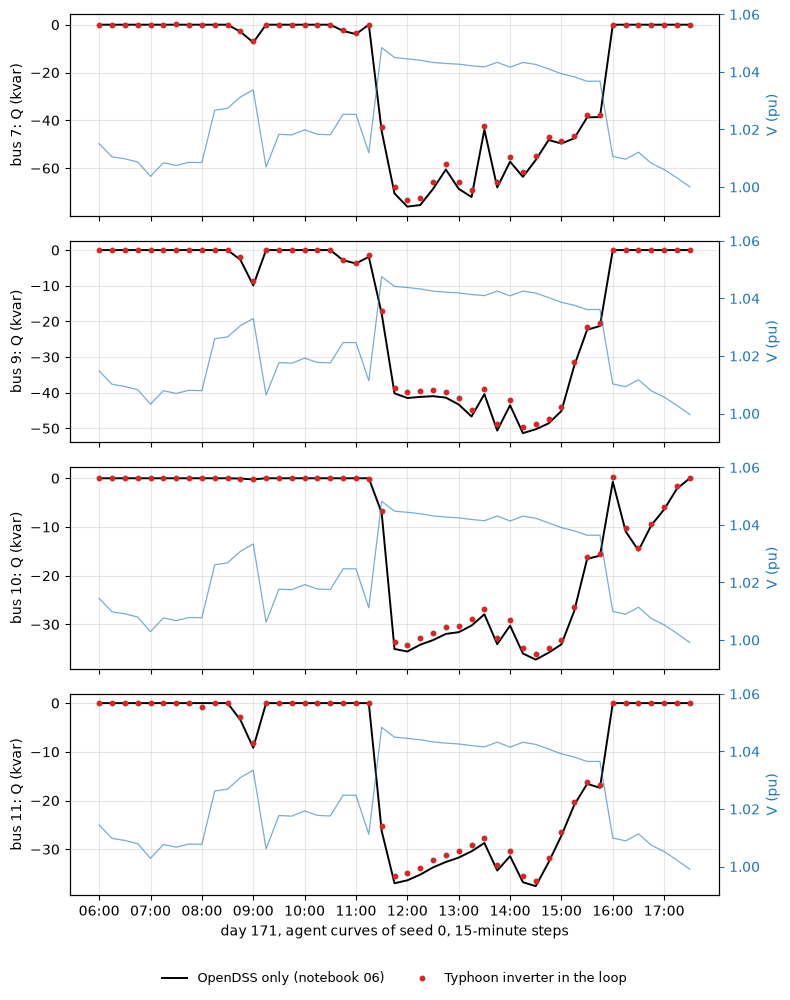

,mean |dV| (pu),max |dV| (pu),mean |dQ| (kvar),max |dQ| (kvar),"Q absorbed, OpenDSS (kvarh)","Q absorbed, Typhoon (kvarh)",mean P gap (kW)
bus,,,,,,,
7,0.00044,0.00072,0.81,2.90,266.4,257.0,12.5
9,0.00043,0.00070,0.60,1.94,185.0,178.0,12.9
10,0.00045,0.00074,0.47,1.51,144.7,139.3,12.7
11,0.00046,0.00075,0.47,1.53,139.9,134.8,12.5


In [4]:
x = np.arange(len(day)); tt = day.time.values
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)
for a, b in zip(axes, UNITS):
    a.plot(x, day[f"Q_dss_kvar_{b}"], color="black", lw=1.4, label="OpenDSS only (notebook 06)")
    a.plot(x, day[f"Q_cosim_kvar_{b}"], "o", color="tab:red", ms=3.2, label="Typhoon inverter in the loop")
    a.set_ylabel(f"bus {b}: Q (kvar)"); a.grid(alpha=0.3)
    a2 = a.twinx(); a2.plot(x, day[f"V_cosim_{b}"], color="tab:blue", lw=0.9, alpha=0.6); a2.set_ylim(0.99, 1.06)
    a2.set_ylabel("V (pu)", color="tab:blue"); a2.tick_params(axis="y", colors="tab:blue")
axes[-1].set_xticks(x[::4]); axes[-1].set_xticklabels(tt[::4]); axes[-1].set_xlabel(f"day {DAY}, agent curves of seed {SEED}, 15-minute steps")
axes[-1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False)
fig.tight_layout(); fig.savefig(os.path.join("../figures", "08_01_day.png"), dpi=150, bbox_inches="tight"); plt.show()

rows = []
for b in UNITS:
    dv = (day[f"V_dss_{b}"] - day[f"V_cosim_{b}"]).abs(); dq = (day[f"Q_dss_kvar_{b}"] - day[f"Q_cosim_kvar_{b}"]).abs()
    dp = day[f"P_dss_kW_{b}"] - day[f"P_cosim_kW_{b}"]
    rows.append({"bus": b, "mean |dV| (pu)": round(dv.mean(), 5), "max |dV| (pu)": round(dv.max(), 5),
                 "mean |dQ| (kvar)": round(dq.mean(), 2), "max |dQ| (kvar)": round(dq.max(), 2),
                 "Q absorbed, OpenDSS (kvarh)": round(-day[f"Q_dss_kvar_{b}"].clip(upper=0).sum() * 0.25, 1),
                 "Q absorbed, Typhoon (kvarh)": round(-day[f"Q_cosim_kvar_{b}"].clip(upper=0).sum() * 0.25, 1),
                 "mean P gap (kW)": round(dp.mean(), 1)})
diff = pd.DataFrame(rows).set_index("bus"); diff

The dots sit on the lines all day. The voltages agree to half a millivolt per unit and the
reactive powers to about one kvar, on units that absorb up to 75 kvar. The one systematic
difference is the active power: the Typhoon inverter delivers about 2 % less than OpenDSS's
lossless, perfectly tracking PVSystem, so its bus rises a little less and it absorbs 2 to
3 % less. At 15-minute resolution the study's static inverter is a fair stand-in for a
dynamic one.

## 5. The seconds the study never saw

At 11:30 the irradiance jumps from 0.28 to 0.93 pu within one step, the largest change of
the day. The capture below starts with that step. The top panel is the terminal voltage of
the four inverters, the bottom their reactive power at feeder scale; the dotted lines mark
the one-second exchanges with OpenDSS.

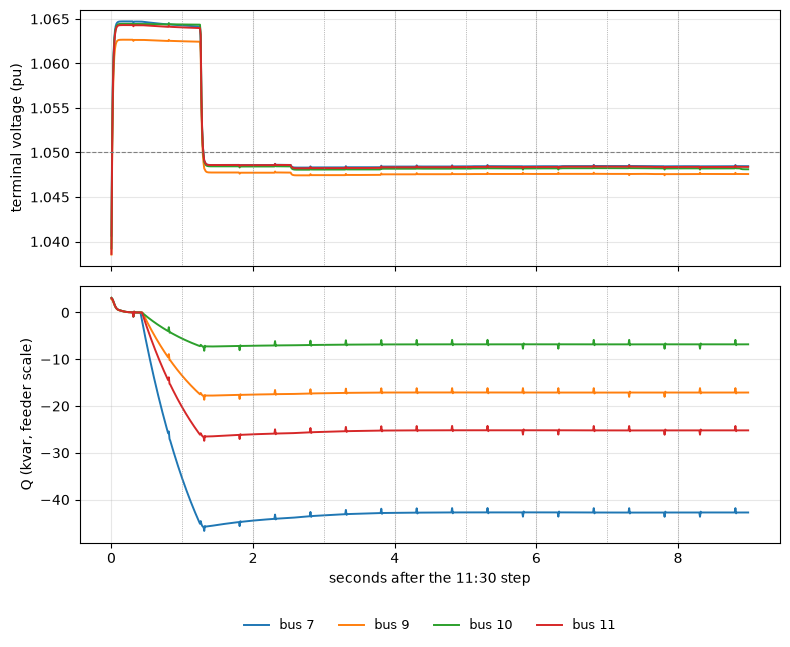

highest terminal voltage 1.0647 pu; time above 1.05 pu 1.28 s per inverter
bus 7: Q    2.9 ->  -42.8 kvar, settled within 5 % after 1.81 s
bus 9: Q    2.7 ->  -17.1 kvar, settled within 5 % after 1.81 s
bus 10: Q    3.0 ->   -6.8 kvar, settled within 5 % after 1.81 s
bus 11: Q    2.9 ->  -25.2 kvar, settled within 5 % after 1.81 s


In [5]:
t = tr.t_s.values
fig, axes = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True)
for b in UNITS:
    axes[0].plot(t, tr[f"V_pu_{b}"], lw=1.4, label=f"bus {b}")
    axes[1].plot(t, tr[f"Q_var_{b}"] * SCALE[b] / 1e3, lw=1.4, label=f"bus {b}")
axes[0].axhline(1.05, color="grey", lw=0.8, ls="--"); axes[0].set_ylabel("terminal voltage (pu)")
axes[1].set_ylabel("Q (kvar, feeder scale)"); axes[1].set_xlabel("seconds after the 11:30 step")
for a in axes:
    a.grid(alpha=0.3)
    for h in range(1, HANDSHAKES + 1):
        a.axvline(h, color="grey", lw=0.5, ls=":")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
fig.tight_layout(); fig.savefig(os.path.join("../figures", "08_02_transient.png"), dpi=150, bbox_inches="tight"); plt.show()

vmax = max(tr[f"V_pu_{b}"].max() for b in UNITS)
above = sum((tr[f"V_pu_{b}"] > 1.05).sum() for b in UNITS) / len(UNITS) * (t[1] - t[0])
print(f"highest terminal voltage {vmax:.4f} pu; time above 1.05 pu {above:.2f} s per inverter")
for b in UNITS:
    q = tr[f"Q_var_{b}"].values * SCALE[b] / 1e3
    k0 = int(np.argmax(np.abs(np.diff(q)) > 0.05)) + 1
    qf = q[-100:].mean(); band = max(0.05 * abs(qf - q[k0]), 1.0)   # 5 % of the change, at least 1 kvar (the 1 s exchanges leave small blips)
    out = np.where(np.abs(q[k0:] - qf) > band)[0]
    print(f"bus {b}: Q {q[k0]:6.1f} -> {qf:6.1f} kvar, settled within 5 % after {t[k0 + out[-1] + 1] - t[k0]:.2f} s")

For the first second the feeder holds the reactive power of the previous step, which was
zero, so the sun jump lifts all four buses to about 1.064 pu, above the limit the study
reports as never crossed. The inverters see it and start absorbing at once; at the second
exchange OpenDSS solves with their Q and the voltage drops to 1.048 pu, and the reactive
power settles within about two seconds, bus 7 taking the most and bus 10 the least, as the
agent's curves prescribe. Part of the overshoot is the loop itself, which changes the
irradiance in one step where the real sky takes seconds, but the point stands: "zero hours
above 1.05 pu" is a 15-minute statement, and what happens inside a minute is decided by
how fast the local controller acts, which is a question for real-time tests and not for a
power-flow study.

## 6. What this adds to the study

1. **The inverter obeys the curve.** For any V3, V4, Q4 the dynamic model delivers the
   reactive power the curve asks for, to within a fraction of a percent, so the static
   inverter of notebooks 01 to 07 is a fair model at 15-minute resolution.
2. **The day is reproduced.** With four dynamic inverters in the loop the bus voltages
   agree to 0.0005 pu and the reactive powers to about 1 kvar; the 2 % gap in active power
   is MPPT and losses that the static model ignores.
3. **Curve points can be changed while the inverter runs.** Every 15 minutes the agent's
   new points were written to running inverters with no jump in current and no trip; the
   reactive power moves to the new curve within about two seconds.
4. **The 15-minute view hides seconds above the limit.** After a sharp irradiance rise the
   far buses spent about a second at 1.064 pu before the inverters pulled them back.
5. **Two practical lessons.** Switch an inverter model on only after its PLL has locked;
   and in any co-simulation hold the inverter's measured terminal, not its source, at the
   bus voltage, or the reactive power comes out 1.6 to 2 times too large.

What it does not add: real time. Virtual HIL runs the same model slower than the clock, so
the settling times are simulation seconds. Running the same model and loop on a HIL device
is the natural next step, and the model already targets one.

In [6]:
print(f"notebook time {time.perf_counter() - T_NB0:.0f} s")

notebook time 1 s
